by Annisa DSML 43

## Hands On - Intermediate Data Types and Structure With Python

### Data Frame

In [1]:
import pandas as pd #untuk manipulasi data

# Create DataFrame from dictionary
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Contract': ['Month-to-month', 'One year', 'Two year']
}

df = pd.DataFrame(data) #ubah jd data frame
df

,Name,Age,Contract
0,Alice,25,Month-to-month
1,Bob,30,One year
2,Charlie,35,Two year


In [4]:
batch_43 = {
    'Student_Name' : ['Decky', 'Ica', 'Narai', 'Made', 'Aley'],
    'Age' : [20, 23, 25, 26, None],
    'Gender' : ['Male', 'Female', 'Female', 'Male', 'Female']
}
type(batch_43)

dict

In [5]:
print(batch_43)

{'Student_Name': ['Decky', 'Ica', 'Narai', 'Made', 'Aley'], 'Age': [20, 23, 25, 26, None], 'Gender': ['Male', 'Female', 'Female', 'Male', 'Female']}


In [6]:
import pandas as pd

bio = pd.DataFrame(batch_43)
bio

,Student_Name,Age,Gender
0,Decky,20.0,Male
1,Ica,23.0,Female
2,Narai,25.0,Female
3,Made,26.0,Male
4,Aley,NaN,Female


In [7]:
# Inspect data
print("First 3 rows:")
print(df.head(3)) # kalo ambil 5 data pertama : df.head())
print("\nDataFrame info:")
print(df.info())

First 3 rows:
      Name  Age        Contract
0    Alice   25  Month-to-month
1      Bob   30        One year
2  Charlie   35        Two year

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      3 non-null      object
 1   Age       3 non-null      int64 
 2   Contract  3 non-null      object
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes
None


In [8]:
bio.head(3)

,Student_Name,Age,Gender
0,Decky,20.0,Male
1,Ica,23.0,Female
2,Narai,25.0,Female


In [9]:
bio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Student_Name  5 non-null      object 
 1   Age           4 non-null      float64
 2   Gender        5 non-null      object 
dtypes: float64(1), object(2)
memory usage: 252.0+ bytes


In [11]:
bio['Student_Name'] #menampilkan student name

,Student_Name
0,Decky
1,Ica
2,Narai
3,Made
4,Aley


In [12]:
bio[['Student_Name', 'Age', 'Gender']]

,Student_Name,Age,Gender
0,Decky,20.0,Male
1,Ica,23.0,Female
2,Narai,25.0,Female
3,Made,26.0,Male
4,Aley,NaN,Female


In [13]:
df

,Name,Age,Contract
0,Alice,25,Month-to-month
1,Bob,30,One year
2,Charlie,35,Two year


In [14]:
# Select columns
print(df['Name'])          # Single column
print(df[['Name', 'Age']]) # Multiple columns

# Filter rows
print(df[df['Age'] > 28])  # Age > 28

# Add new column
df['Senior'] = df['Age'].apply(lambda x: 'Yes' if x >= 30 else 'No')

0      Alice
1        Bob
2    Charlie
Name: Name, dtype: object
      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   35
      Name  Age  Contract
1      Bob   30  One year
2  Charlie   35  Two year


In [15]:
df[df['Age'] > 25]

,Name,Age,Contract,Senior
1,Bob,30,One year,Yes
2,Charlie,35,Two year,Yes


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      3 non-null      object
 1   Age       3 non-null      int64 
 2   Contract  3 non-null      object
 3   Senior    3 non-null      object
dtypes: int64(1), object(3)
memory usage: 228.0+ bytes


In [17]:
#kolom baru bernama categori kalau age diatas 25 young, <25 kids
bio['Category'] = bio['Age'].apply(lambda x: 'Young' if x > 25 else 'Kids')
bio

,Student_Name,Age,Gender,Category
0,Decky,20.0,Male,Kids
1,Ica,23.0,Female,Kids
2,Narai,25.0,Female,Kids
3,Made,26.0,Male,Young
4,Aley,NaN,Female,Kids


In [18]:
#atau bs pake np.where untuk nambah kolom
import numpy as np

bio['New']=np.where(bio['Age']>25, "Young", "Kids")
bio

,Student_Name,Age,Gender,Category,New
0,Decky,20.0,Male,Kids,Kids
1,Ica,23.0,Female,Kids,Kids
2,Narai,25.0,Female,Kids,Kids
3,Made,26.0,Male,Young,Young
4,Aley,NaN,Female,Kids,Kids


In [19]:
bio['Category_Final'] = bio['Age'].apply(lambda x:"Unknown" if pd.isna(x) else 'Young' if x > 25 else 'Kids')
bio

,Student_Name,Age,Gender,Category,New,Category_Final
0,Decky,20.0,Male,Kids,Kids,Kids
1,Ica,23.0,Female,Kids,Kids,Kids
2,Narai,25.0,Female,Kids,Kids,Kids
3,Made,26.0,Male,Young,Young,Young
4,Aley,NaN,Female,Kids,Kids,Unknown


### Categorical and Continuous Data

In [20]:
df

,Name,Age,Contract,Senior
0,Alice,25,Month-to-month,No
1,Bob,30,One year,Yes
2,Charlie,35,Two year,Yes


In [21]:
# Categorical (limited distinct values : obj dan category
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))

# Continuous (numeric ranges : int dan float)
continuous_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Continuous columns:", list(continuous_cols))

Categorical columns: ['Name', 'Contract', 'Senior']
Continuous columns: ['Age']



Contract types:
Contract
Month-to-month    1
One year          1
Two year          1
Name: count, dtype: int64


<Axes: title={'center': 'Contract Types'}, xlabel='Contract'>

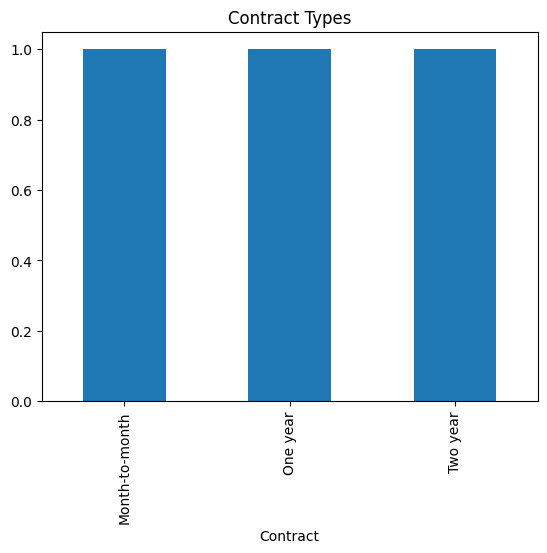

In [22]:
# Count values
print("\nContract types:")
print(df['Contract'].value_counts())

# Visualize
df['Contract'].value_counts().plot(kind='bar', title='Contract Types')


Age statistics:
count     3.0
mean     30.0
std       5.0
min      25.0
25%      27.5
50%      30.0
75%      32.5
max      35.0
Name: Age, dtype: float64


<Axes: title={'center': 'Age Distribution'}, ylabel='Frequency'>

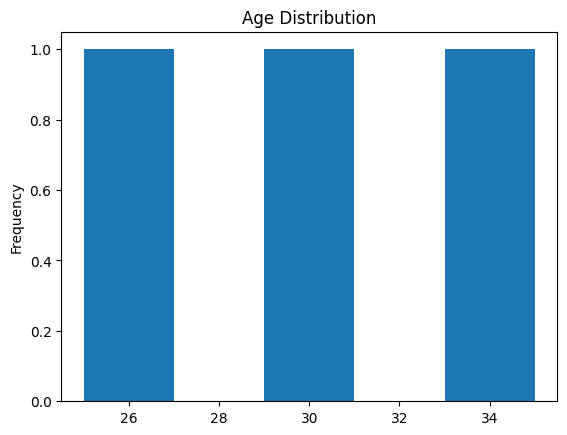

In [23]:
# Summary statistics
print("\nAge statistics:")
print(df['Age'].describe())

# Histogram
df['Age'].plot(kind='hist', bins=5, title='Age Distribution')

In [24]:
df.describe()

,Age
count,3.0
mean,30.0
std,5.0
min,25.0
25%,27.5
50%,30.0
75%,32.5
max,35.0


In [25]:
bio.describe()

,Age
count,4.000000
mean,23.500000
std,2.645751
min,20.000000
25%,22.250000
50%,24.000000
75%,25.250000
max,26.000000


### For Loop

In [26]:
for i in range(1,11):
  print(i)

1
2
3
4
5
6
7
8
9
10


In [27]:
for i in range(100,201):
  print(i)

100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200


In [28]:
df

,Name,Age,Contract,Senior
0,Alice,25,Month-to-month,No
1,Bob,30,One year,Yes
2,Charlie,35,Two year,Yes


In [29]:
#pake itterrows: untuk ngeluarin perbaris, untukl mengulang tiap baris
for index, row in df.iterrows(): #keluarin dr index, baris
  print(f"{row['Name']} is {row['Age']} years old with {row['Contract']} contract")

Alice is 25 years old with Month-to-month contract
Bob is 30 years old with One year contract
Charlie is 35 years old with Two year contract


In [30]:
# Iterate through rows
print("\nCustomer profiles:")
for index, row in df.iterrows():
    print(f"{row['Name']} is {row['Age']} years old with {row['Contract']} contract")

# Column-wise operations
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"Data type: {df[col].dtype}")


Customer profiles:
Alice is 25 years old with Month-to-month contract
Bob is 30 years old with One year contract
Charlie is 35 years old with Two year contract

Column: Name
Data type: object

Column: Age
Data type: int64

Column: Contract
Data type: object

Column: Senior
Data type: object


In [31]:
bio

,Student_Name,Age,Gender,Category,New,Category_Final
0,Decky,20.0,Male,Kids,Kids,Kids
1,Ica,23.0,Female,Kids,Kids,Kids
2,Narai,25.0,Female,Kids,Kids,Kids
3,Made,26.0,Male,Young,Young,Young
4,Aley,NaN,Female,Kids,Kids,Unknown


In [32]:
# my name is student_name and I'm Age years old, and my gender is Gender
for index, row in bio.iterrows():
  print(f"My name is {row['Student_Name']} and I'm {row['Age']} years old, and my gender is {row['Gender']}")

My name is Decky and I'm 20.0 years old, and my gender is Male
My name is Ica and I'm 23.0 years old, and my gender is Female
My name is Narai and I'm 25.0 years old, and my gender is Female
My name is Made and I'm 26.0 years old, and my gender is Male
My name is Aley and I'm nan years old, and my gender is Female


### While Loop

In [33]:
df

,Name,Age,Contract,Senior
0,Alice,25,Month-to-month,No
1,Bob,30,One year,Yes
2,Charlie,35,Two year,Yes


In [34]:
# jika umur sampai 50, stop
total_age = 0 #inisialisasi untuk umnur sementara
i = 0 #index baris yang di baca
print("\nCumulative age check:")
while total_age <= 50 and i < len(df): #selama total age nya masih <50, akan terus ulang
    total_age += df.loc[i, 'Age']
    print(f"Added {df.loc[i, 'Name']}'s age ({df.loc[i, 'Age']}), Total: {total_age}")
    i += 1

#stop sampai bob, krn sdh sampai 50, jd tidak perlu ke charlie


Cumulative age check:
Added Alice's age (25), Total: 25
Added Bob's age (30), Total: 55


### Lambda Function

In [35]:
# Create age group column
df['AgeGroup'] = df['Age'].apply(
    lambda x: 'Young' if x < 30 else ('Middle-aged' if x < 40 else 'Senior')
)

# Calculate squared age
df['AgeSquared'] = df['Age'].apply(lambda x: x**2)
df

,Name,Age,Contract,Senior,AgeGroup,AgeSquared
0,Alice,25,Month-to-month,No,Young,625
1,Bob,30,One year,Yes,Middle-aged,900
2,Charlie,35,Two year,Yes,Middle-aged,1225


In [36]:
# Categorize contracts
df['ContractCategory'] = df['Contract'].apply(
    lambda x: 'Short' if 'month' in x.lower() else 'Long'
)

# Conditional formatting
df['PriceRating'] = df['Age'].apply(
    lambda x: 'High' if x > 30 else ('Medium' if x > 25 else 'Low')
)

In [37]:
df

,Name,Age,Contract,Senior,AgeGroup,AgeSquared,ContractCategory,PriceRating
0,Alice,25,Month-to-month,No,Young,625,Short,Low
1,Bob,30,One year,Yes,Middle-aged,900,Long,Medium
2,Charlie,35,Two year,Yes,Middle-aged,1225,Long,High


### Exercise

In [ ]:
# Task: Calculate the average age for each contract type
# Expected output:
# Contract
# Month-to-month    25.0
# One year          30.0
# Two year          35.0

In [ ]:
# Task: Use a while loop to find how many customers
# needed to reach a cumulative age of 60

In [ ]:
# Task: Create a 'NameLength' column using lambda
# that counts letters in names (spaces excluded)

### Solution

In [38]:
print(df.groupby('Contract')['Age'].mean())


total = 0
count = 0
while total < 60 and count < len(df):
    total += df.loc[count, 'Age']
    count += 1
print(f"Customers needed: {count}")


df['NameLength'] = df['Name'].apply(lambda x: len(x.replace(" ", "")))
print(df[['Name', 'NameLength']])

Contract
Month-to-month    25.0
One year          30.0
Two year          35.0
Name: Age, dtype: float64
Customers needed: 3
      Name  NameLength
0    Alice           5
1      Bob           3
2  Charlie           7


In [39]:
import pandas as pd
data_diabetes = pd.read_csv('/content/Healthcare-Diabetes.csv')
data_diabetes

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
2763,2764,2,75,64,24,55,29.7,0.370,33,0
2764,2765,8,179,72,42,130,32.7,0.719,36,1
2765,2766,6,85,78,0,0,31.2,0.382,42,0
2766,2767,0,129,110,46,130,67.1,0.319,26,1


In [40]:
data_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB


## Impelementation with Students Data

In [41]:
five_students = {

    'Nama':['Intan','Dana','Elizabeth','Suho','Sehun'],

    'Jabatan':['Student','Student','Alumni','Intern','Alumni'],

    'Umur':[25,25,20,27,26],

    'Tingkat_Pendidikan':["Bachelor's","Bachelor's","Bachelor's","Master's","Master's"],

    'Status_Perkawinan':["Married","Single","Married","Divorce","Single"],

}

students = pd.DataFrame(five_students)

students

,Nama,Jabatan,Umur,Tingkat_Pendidikan,Status_Perkawinan
0,Intan,Student,25,Bachelor's,Married
1,Dana,Student,25,Bachelor's,Single
2,Elizabeth,Alumni,20,Bachelor's,Married
3,Suho,Intern,27,Master's,Divorce
4,Sehun,Alumni,26,Master's,Single


In [42]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Nama                5 non-null      object
 1   Jabatan             5 non-null      object
 2   Umur                5 non-null      int64 
 3   Tingkat_Pendidikan  5 non-null      object
 4   Status_Perkawinan   5 non-null      object
dtypes: int64(1), object(4)
memory usage: 332.0+ bytes


In [43]:
students['Umur'].min()

20

In [44]:
students.describe()

,Umur
count,5.000000
mean,24.600000
std,2.701851
min,20.000000
25%,25.000000
50%,25.000000
75%,26.000000
max,27.000000


<Axes: title={'center': 'Status Perkawinan'}, xlabel='Status_Perkawinan'>

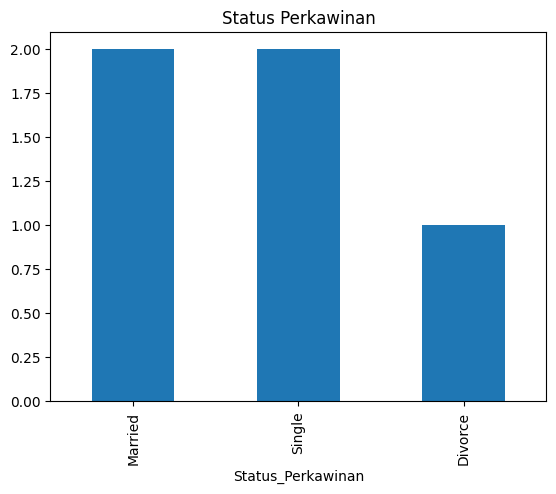

In [45]:
# Visualize
students['Status_Perkawinan'].value_counts().plot(kind='bar', title='Status Perkawinan')

Dari plot diatas, students terbanyak memiliki status married dan single

In [46]:
students

,Nama,Jabatan,Umur,Tingkat_Pendidikan,Status_Perkawinan
0,Intan,Student,25,Bachelor's,Married
1,Dana,Student,25,Bachelor's,Single
2,Elizabeth,Alumni,20,Bachelor's,Married
3,Suho,Intern,27,Master's,Divorce
4,Sehun,Alumni,26,Master's,Single
